# MATRIX FDR Thermal Design

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

STEFAN_BOLTZMANN = 5.67e-8  # W/(m^2·K^4)
T_SPACE = 2.7  # Space temperature in Kelvin (cosmic background radiation)

## Defining the components of a spacecraft node

In [54]:
class SurfaceComponent:
    """Represents a single surface component of the spacecraft"""
    def __init__(self, name, area, em, absBOL, absEOL, orientation):
        self.name = name 
        self.A = area #m^2
        self.epsilon = em
        self.alpha_BOL = absBOL
        self.alpha_EOL = absEOL
        self.orientation = orientation  # 'sun-facing', 'earth-facing', 'space-facing'

class Louver:
    def __init__(self, area, emClosed, absOpen, emOpen, Topen, Tclosed):
        self.A = area #m^2
        self.emClosed = emClosed
        self.alphaOpen = absOpen
        self.emOpen = emOpen
        self.Topen = Topen
        self.Tclosed = Tclosed

    def effEmm(self, T):
        if T <= self.Tclosed:
            return self.emClosed
        elif T >= self.Topen:
            return self.emOpen
        return self.emOpen - (self.emOpen - self.emClosed) * (1 - T/self.Topen) / (1 - self.Tclosed/self.Topen)
    
    def radiative_loss(self, T):
        return self.effEmm(T) * STEFAN_BOLTZMANN * self.A * (T**4 - T_SPACE**4)

## Defining Enviornmental Heat Inputs

Defined based on side of spacecraft and View Factors for MATRIX Design

Based on MATRIX Hot & Cold Cases

Eclipse at Apogee

RAAN precesses on a yearly period but these remain the most extreme cases


In [55]:
class heatInputs:
    def __init__(self, panelSide, spaceSide, thrusterSide):
        self.panelSide = panelSide
        self.spaceSide = spaceSide
        self.thrusterSide = thrusterSide

    def total(self):
        return self.panelSide + self.spaceSide + self.thrusterSide


solar = 1361
albedo = 63.5
ir = 245.5

envHot = heatInputs(panelSide=solar, spaceSide=0.2 * (albedo + ir), thrusterSide=0.76 * (albedo + ir))
envCold = heatInputs(panelSide=0.013*ir, spaceSide=0, thrusterSide=0)


## Defining a Node of the spacecraft

In [56]:
class Node:
    def __init__(self, components, louver):
        self.components = components
        self.louver = louver
    
    def heatEq(self, T, env, BOL):
        absorbed = 0
        emitted = 0
        for comp in self.components:
            if BOL:
                if comp.orientation == 'sun-facing':
                    absorbed += comp.alpha_BOL * env.panelSide * comp.A
                elif comp.orientation == 'earth-facing':
                    absorbed += comp.alpha_BOL * env.spaceSide * comp.A
                elif comp.orientation == 'space-facing':
                    absorbed += comp.alpha_BOL * env.thrusterSide * comp.A
            else:
                if comp.orientation == 'sun-facing':
                    absorbed += comp.alpha_EOL * env.panelSide * comp.A
                elif comp.orientation == 'earth-facing':
                    absorbed += comp.alpha_EOL * env.spaceSide * comp.A
                elif comp.orientation == 'space-facing':
                    absorbed += comp.alpha_EOL * env.thrusterSide * comp.A
            
            emitted += comp.epsilon * STEFAN_BOLTZMANN * (T**4 - T_SPACE **4) * comp.A
        
        # Louver contribution
        emitted += self.louver.radiative_loss(T)
        
        return absorbed - emitted
    

## Defining Internodal Connections

In [57]:
class ConductiveConnection:
    def __init__(self, node1_index, node2_index, k, L, A):
        self.node1_idx = node1_index
        self.node2_idx = node2_index
        self.k = k  # Thermal conductance (W/m*K)
        self.L = L
        self.A = A
    
    def calculate_heat_transfer(self, T1, T2):
        return self.k * (T1 - T2) * self.A / self.L
    
class RadiativeConnection: #Only works for F=1
    def __init__(self, node1_index, node2_index, emm1, emm2, A):
        self.node1_idx = node1_index
        self.node2_idx = node2_index
        self.emm1 = emm1
        self.emm2 = emm2
        self.A = A
    
    def calculate_heat_transfer(self, T1, T2):
        efemm = 1 / (1/self.emm1 + 1/self.emm2 - 1)  # Effective emissivity for two surfaces
        return efemm * STEFAN_BOLTZMANN * (T1**4 - T2**4) * self.A

## Defining a Spacecraft

In [58]:
class spacecraft:
    def __init__(self, nodes, cond, rad):
        self.nodes = nodes
        self.cond = cond
        self.rad = rad

    def eqTemp(self, env, BOL, heaters):
        temps = np.ones(len(self.nodes)) * 300  # Initial guess for temperatures

        def equations(temps, envmt, BOL, heaters):
            eqs = np.zeros(len(self.nodes)) * 1000
            for i, node in enumerate(self.nodes):
                eqs[i] = node.heatEq(temps[i], envmt, BOL) + heaters[i]
            
            for cond in self.cond:
                T1 = temps[cond.node1_idx]
                T2 = temps[cond.node2_idx]
                q_cond = cond.calculate_heat_transfer(T1, T2)
                eqs[cond.node1_idx] -= q_cond
                eqs[cond.node2_idx] += q_cond
        
            for rad in self.rad:
                T1 = temps[rad.node1_idx]
                T2 = temps[rad.node2_idx]
                q_rad = rad.calculate_heat_transfer(T1, T2)
                eqs[rad.node1_idx] -= q_rad
                eqs[rad.node2_idx] += q_rad

            return eqs
        
        return fsolve(lambda T: equations(T, env, BOL, heaters), temps)
    
    def incomingFluxes(self, env):
        fluxes = 0
        for i, node in enumerate(self.nodes):
            for comp in node.components:
                if comp.orientation == 'sun-facing':
                    fluxes += env.panelSide * comp.A
                elif comp.orientation == 'earth-facing':
                    fluxes += env.spaceSide * comp.A
                elif comp.orientation == 'space-facing':
                    fluxes += env.thrusterSide * comp.A
        return fluxes

# MATRIX Spacecraft Components

We assume three nodes: structure, tanks, and magnetometer

thermal straps are considred infinitely high thermal conductivity
assume all internal radiation view factors are 1

There are actually 6 tanks but we assume one node with all tanks connected with heat straps
It is also assume that a body-mounted louver is associated with the tanks
assume that this louver is attached by g-10 to the structure, and lovuer is connected to the tanks via thermal strap

All other interal components with stricter thermal req are mounted with g-10
Since they have smal thermal mass, assume that they are thermally conducted to tanks and not significant heater req

In [59]:
structure = Node(components=[
        SurfaceComponent("Solar Cells", area=0.5, em=0.5, absBOL=0.112, absEOL = 0.322, orientation='sun-facing'),
        SurfaceComponent("Alum", area=0.048, em=0.03, absBOL=0.9, absEOL = 0.945, orientation='space-facing'),
        SurfaceComponent("Alum2", area=0.024, em=0.03, absBOL=0.9, absEOL = 0.945, orientation='earth-facing'),
        SurfaceComponent("Antenna1", area=0.013944, em=0.88, absBOL=0.2, absEOL = 0.62, orientation='earth-facing'),
        SurfaceComponent("Antenna2", area=0.013944, em=0.88, absBOL=0.2, absEOL = 0.62, orientation='sun-facing'),
        SurfaceComponent("MLISun", area=0.366, em=0.0045, absBOL=0.04, absEOL = 0.31, orientation='sun-facing'),
        SurfaceComponent("MLIEarth", area=0.631, em=0.0045, absBOL=0.04, absEOL = 0.31, orientation='earth-facing'),
        SurfaceComponent("MLISpace", area=0.28151616, em=0.0045, absBOL=0.04, absEOL = 0.31, orientation='space-facing')
        ],
        louver=Louver(area=0.75, emClosed=0.1, absOpen = 0.45, emOpen = 0.7, Topen = 40 + 273.15, Tclosed = 20 + 273.15)
)

hydrazineBig = Node(components=[SurfaceComponent("MLIEarth", area=0.29, em=0.0045, absBOL=0.04, absEOL = 0.31, orientation='earth-facing')],
                    louver=Louver(area=0.25, emClosed=0.1, absOpen=0.45, emOpen=0.7, Topen=25 + 273.15, Tclosed=5 + 273.15))

hydrazineSmall1 = Node(components=[SurfaceComponent("MLIEarth", area=0.0, em=0.0045, absBOL=0.04, absEOL = 0.31, orientation='earth-facing')],
                    louver=Louver(area=0.0, emClosed=0.1, absOpen=0.45, emOpen=0.7, Topen=25 + 273.15, Tclosed=5 + 273.15)) #fully internal componenents

hydrazineSmall2 = Node(components=[SurfaceComponent("MLIEarth", area=0.0, em=0.0045, absBOL=0.04, absEOL = 0.31, orientation='earth-facing')],
                    louver=Louver(area=0.0, emClosed=0.1, absOpen=0.45, emOpen=0.7, Topen=25 + 273.15, Tclosed=5 + 273.15)) #fully internal componenents

magnetometer = Node(components = [SurfaceComponent("GoldSpace", area=0.00810708, em=0.02, absBOL=0.06, absEOL = 0.06, orientation='space-facing'),
        SurfaceComponent("GoldSun", area=0.0129032, em=0.02, absBOL=0.06, absEOL = 0.06, orientation='sun-facing'),
        SurfaceComponent("GoldEarth", area=0.0129032, em=0.02, absBOL=0.06, absEOL = 0.06, orientation='earth-facing'),
        SurfaceComponent("Alum", area=0.00802192, em=0.85, absBOL=0.9, absEOL = 0.945, orientation='space-facing')
        ],
        louver=Louver(area=0.0, emClosed=0.1, absOpen=0.45, emOpen=0.7, Topen=30 + 273.15, Tclosed=10 + 273.15)
)

instruments = Node(components=[SurfaceComponent("MLI", area=0.0364818625, em=0.0045, absBOL=0.04, absEOL = 0.31, orientation='space-facing')],
                    louver=Louver(area=0.0, emClosed=0.1, absOpen=0.45, emOpen=0.7, Topen=30 + 273.15, Tclosed=10 + 273.15)
)

battery = Node(components = [SurfaceComponent("spacefiller", area=0.0, em=0.0045, absBOL=0.04, absEOL = 0.31, orientation='space-facing')], louver = Louver(area=0.0, emClosed=0.1, absOpen=0.45, emOpen=0.7, Topen=30 + 273.15, Tclosed=10 + 273.15)) #fully internal component


nodeNames = ["Structure", "Main Hydrazine Tank", "First Small Hydrazine Tank", "Second Small Hydrazine Tank","Magnetometer", "Instruments", "Battery"]

nodes = [structure, hydrazineBig, hydrazineSmall1, hydrazineSmall2, magnetometer, instruments, battery]



In [60]:
cond = [
    ConductiveConnection(node1_index=0, node2_index=1, k=0.25, L=0.215, A=0.0012566*8), # structure + hydrazine tank braces
    ConductiveConnection(node1_index=0, node2_index=1, k=0.25, L=0.02, A=0.0508923 / 4),  # structure + hydrazine tank ring brace
    ConductiveConnection(node1_index=0, node2_index=2, k=0.25, L=0.1, A=0.0012566*16),  # structure + extra hydrazine conductive coupling
    ConductiveConnection(node1_index=1, node2_index=2, k=1700, L=0.1, A=0.001),  # main tank + small tanks conductive strap
    ConductiveConnection(node1_index=0, node2_index=3, k=0.25, L=0.1, A=0.0012566*16),  # structure + extra hydrazine conductive coupling
    ConductiveConnection(node1_index=1, node2_index=3, k=1700, L=0.1, A=0.001),  # main tank + small tanks conductive strap
    ConductiveConnection(node1_index=0, node2_index=4, k=5, L=1, A=0.01266731),  # structure + magnetometer conductive coupling
    ConductiveConnection(node1_index=1, node2_index=5, k=1700, L=0.1524, A=0.001),  # tank + instruments conduction strap
    ConductiveConnection(node1_index=0, node2_index=5, k=0.25, L=0.025, A=0.0064516),  # structure + instruments mounting
    ConductiveConnection(node1_index=1, node2_index=6, k=1700, L=0.1, A=0.0064516),  # tank + battery conduction strap
    ConductiveConnection(node1_index=0, node2_index=6, k=0.25, L=0.025, A=0.016129)  # structure + battery mounting
]


rad = [
    RadiativeConnection(node1_index=0, node2_index=1, emm1=0.85, emm2=0.0045, A=0.97636249),  # structure + hydrazine tank radiative coupling
    RadiativeConnection(node1_index=0, node2_index=2, emm1=0.85, emm2=0.0045, A=0.7496759),  # structure + hydrazine tank radiative coupling
    RadiativeConnection(node1_index=0, node2_index=3, emm1=0.85, emm2=0.0045, A=0.7496759),  # structure + hydrazine tank radiative coupling
    RadiativeConnection(node1_index=0, node2_index=6, emm1=0.85, emm2=0.0045, A=0.148387)  # structure + battery radiative coupling
]

In [ ]:
matrix = spacecraft(nodes=nodes, cond = cond, rad = rad)

print(matrix.incomingFluxes(envHot))
print(matrix.incomingFluxes(envCold))



1364.9639061239002
2.8495218388000003


## Verification Testing

In [62]:
testNode1 = Node(components=[SurfaceComponent("TestComp", area=1, em=1, absBOL=1, absEOL=1, orientation='sun-facing')],
                    louver=Louver(area=0, emClosed=0.5, absOpen=0.5, emOpen=1, Topen=40 + 273.15, Tclosed=-40 + 273.15))
testNode2 = Node(components=[SurfaceComponent("TestComp", area=1, em=0.1, absBOL=1, absEOL=1, orientation='sun-facing')],
                    louver=Louver(area=0, emClosed=0.5, absOpen=0.5, emOpen=1, Topen=40 + 273.15, Tclosed=-40 + 273.15))

testInputs = heatInputs(panelSide=2, spaceSide=0, thrusterSide=0)

testCond = [ConductiveConnection(node1_index=0, node2_index=1, k=0.0, L=0.1, A=1)]

testRad = [RadiativeConnection(node1_index=0, node2_index=1, emm1=1, emm2=0.01, A=1)]

testCraft = spacecraft(nodes=[testNode1, testNode2], cond=testCond, rad=testRad)


temps = testCraft.eqTemp(testInputs, BOL=True, heaters=[0,0])
print("Equilibrium Temperatures (°K):", temps)

Equilibrium Temperatures (°K): [ 78.58261058 134.17791845]


## Optimizer

In [63]:
from scipy.optimize import minimize, differential_evolution, NonlinearConstraint

def create_optimizer_hybrid(env, BOL, case_name):
    """
    Hybrid optimizer using differential_evolution (global) + minimize (local refinement)
    Provides stable, global optimization without overshooting
    """
    
    def constraint_function(heaters):
        """Returns negative if constraints violated, positive if satisfied (all must be >= 0)"""
        temps = matrix.eqTemp(env, BOL=BOL, heaters=heaters)
        
        # All temperature constraints (in Celsius) - all must be non-negative
        constraints = [
            temps[0] - 273.15 + 89,      # Node 0: > -89°C.  Structure
            89 - (temps[0] - 273.15),    # Node 0: < 89°C
            temps[1] - 273.15 - 4,       # Node 1: > 4°C.     Main Tank
            50 - (temps[1] - 273.15),    # Node 1: < 50°C
            temps[2] - 273.15 - 4,       # Node 2: > 4°C.   Small Tank 1
            50 - (temps[2] - 273.15),    # Node 2: < 50°C
            temps[3] - 273.15 - 4,       # Node 3: > 4°C.   Small Tank 2
            50 - (temps[3] - 273.15),    # Node 3: < 50°C
            temps[4] - 273.15 + 20,      # Node 4: > -20°C.  Magnetometer
            60 - (temps[4] - 273.15),    # Node 4: < 60°C
            temps[5] - 273.15 + 20,      # Node 3: > -20°C.  Instruments
            60 - (temps[5] - 273.15),    # Node 3: < 60°C
            temps[6] - 273.15 + 20,      # Node 4: > -20°C.  Battery
            60 - (temps[6] - 273.15)     # Node 4: < 60°C
        ]
        return np.min(constraints)
    
    def objective(heaters):
        """Minimize total heater power (sum of all heaters)"""
        return np.sum(heaters)
    
    def constraint_penalty(heaters):
        """For differential_evolution: penalizes constraint violations"""
        constraint_val = constraint_function(heaters)
        if constraint_val < 0:
            # Heavy penalty for constraint violations
            return objective(heaters) + 1000 * abs(constraint_val)
        return objective(heaters)
    
    # Bounds for each heater
    bounds = [(0, 50), (0, 50), (0, 30), (0, 30), (0, 15), (0, 15), (0, 15)]
    
    print(f"  [Global Search] Using differential_evolution...", end=" ", flush=True)
    
    # STEP 1: Global search using differential_evolution with penalty method
    result_global = differential_evolution(
        constraint_penalty, bounds, seed=42, maxiter=500, 
        atol=0, tol=1e-4, workers=1, popsize=15
    )
    
    print(f"✓ Found candidate solution ({objective(result_global.x):.2f} W)")
    
    # STEP 2: Local refinement using SLSQP starting from global solution
    print(f"  [Local Refinement] Using minimize (SLSQP)...", end=" ", flush=True)
    
    # Create NonlinearConstraint for minimize
    constraint_obj = NonlinearConstraint(constraint_function, 0, np.inf)
    
    result_local = minimize(
        objective, result_global.x, method='SLSQP', bounds=bounds,
        constraints=constraint_obj, options={'ftol': 1e-9, 'maxiter': 2000}
    )
    
    print(f"✓ Refined to {objective(result_local.x):.2f} W")
    
    # Use the better of the two solutions
    result = result_local if objective(result_local.x) < objective(result_global.x) else result_global
    
    # Print results
    print(f"\033[1m{case_name}\033[0m")
    if constraint_function(result.x) >= -1e-6:  # Allow small numerical tolerance
        print(f"  Minimum heater power for node 1: {result.x[0]:.3f} W")
        print(f"  Minimum heater power for node 2: {result.x[1]:.3f} W")
        print(f"  Minimum heater power for node 3: {result.x[2]:.3f} W")
        print(f"  Minimum heater power for node 4: {result.x[3]:.3f} W")
        print(f"  Minimum heater power for node 5: {result.x[4]:.3f} W")
        print(f"  Minimum heater power for node 6: {result.x[5]:.3f} W")
        print(f"  Minimum heater power for node 7: {result.x[6]:.3f} W")

        print(f"  Total minimum power: {objective(result.x):.3f} W")
        return result.x
    else:
        print("  ⚠ No feasible solution found (constraint violation)")
        return None

# Run optimizations for all four cases
print("="*70)
print("OPTIMIZED HEATER POWER MINIMIZATION (Hybrid Global + Local Optimization)")
print("="*70)
print()

heater_hot_bol = create_optimizer_hybrid(envHot, BOL=True, case_name="BOL, Hot Case:")
print()
heater_hot_eol = create_optimizer_hybrid(envHot, BOL=False, case_name="EOL, Hot Case:")
print()
heater_cold_bol = create_optimizer_hybrid(envCold, BOL=True, case_name="BOL, Cold Case:")
print()
heater_cold_eol = create_optimizer_hybrid(envCold, BOL=False, case_name="EOL, Cold Case:")
print()
print("="*70)


OPTIMIZED HEATER POWER MINIMIZATION (Hybrid Global + Local Optimization)

  [Global Search] Using differential_evolution... 

KeyboardInterrupt: 

## Simulations

In [65]:
heaters = [0,35.632, 4.606, 4.151, 4.467, 0, 0]

temps = matrix.eqTemp(env = envCold, BOL = False, heaters = heaters)

for i, node in enumerate(matrix.nodes):
    print(f"Node {i} ({nodeNames[i]}): {temps[i] - 273.15:.2f} C")

for i, cond in enumerate(matrix.cond):
    node1_temp = temps[cond.node1_idx]
    node2_temp = temps[cond.node2_idx]
    heat_transfer = cond.calculate_heat_transfer(node1_temp, node2_temp)
    print(f"Conductive Connection {i} ({nodeNames[cond.node1_idx]} to {nodeNames[cond.node2_idx]}): {heat_transfer:.2f} W")

for i, rad in enumerate(matrix.rad):
    node1_temp = temps[rad.node1_idx]
    node2_temp = temps[rad.node2_idx]
    heat_transfer = rad.calculate_heat_transfer(node1_temp, node2_temp)
    print(f"Radiative Connection {i} ({nodeNames[rad.node1_idx]} to {nodeNames[rad.node2_idx]}): {heat_transfer:.2f} W")



Node 0 (Structure): -63.34 C
Node 1 (Main Hydrazine Tank): 3.19 C
Node 2 (First Small Hydrazine Tank): 3.22 C
Node 3 (Second Small Hydrazine Tank): 3.19 C
Node 4 (Magnetometer): -20.24 C
Node 5 (Instruments): 2.80 C
Node 6 (Battery): 3.09 C
Conductive Connection 0 (Structure to Main Hydrazine Tank): -0.78 W
Conductive Connection 1 (Structure to Main Hydrazine Tank): -10.58 W
Conductive Connection 2 (Structure to First Small Hydrazine Tank): -3.35 W
Conductive Connection 3 (Main Hydrazine Tank to First Small Hydrazine Tank): -0.52 W
Conductive Connection 4 (Structure to Second Small Hydrazine Tank): -3.34 W
Conductive Connection 5 (Main Hydrazine Tank to Second Small Hydrazine Tank): -0.06 W
Conductive Connection 6 (Structure to Magnetometer): -2.73 W
Conductive Connection 7 (Main Hydrazine Tank to Instruments): 4.32 W
Conductive Connection 8 (Structure to Instruments): -4.27 W
Conductive Connection 9 (Main Hydrazine Tank to Battery): 10.86 W
Conductive Connection 10 (Structure to Batte

## Visualizations


                     THERMAL EQUILIBRIUM SUMMARY                      

Equilibrium Temperatures:
  Structure              -76.01 °C  (  197.1 K)
  Hydrazine Tank          -0.31 °C  (  272.8 K)
  Magnetometer           -23.22 °C  (  249.9 K)

Heater Inputs:
  Structure                23.0 W
  Hydrazine Tank           26.0 W
  Magnetometer              5.0 W

Conductive Heat Transfer Rates:
  Structure ← Hydrazine Tank           0.88 W
  Structure ← Hydrazine Tank          12.04 W
  Structure ← Hydrazine Tank           3.81 W
  Structure ← Magnetometer             3.34 W

Radiative Heat Transfer Rates:
  Structure ← Hydrazine Tank           1.00 W




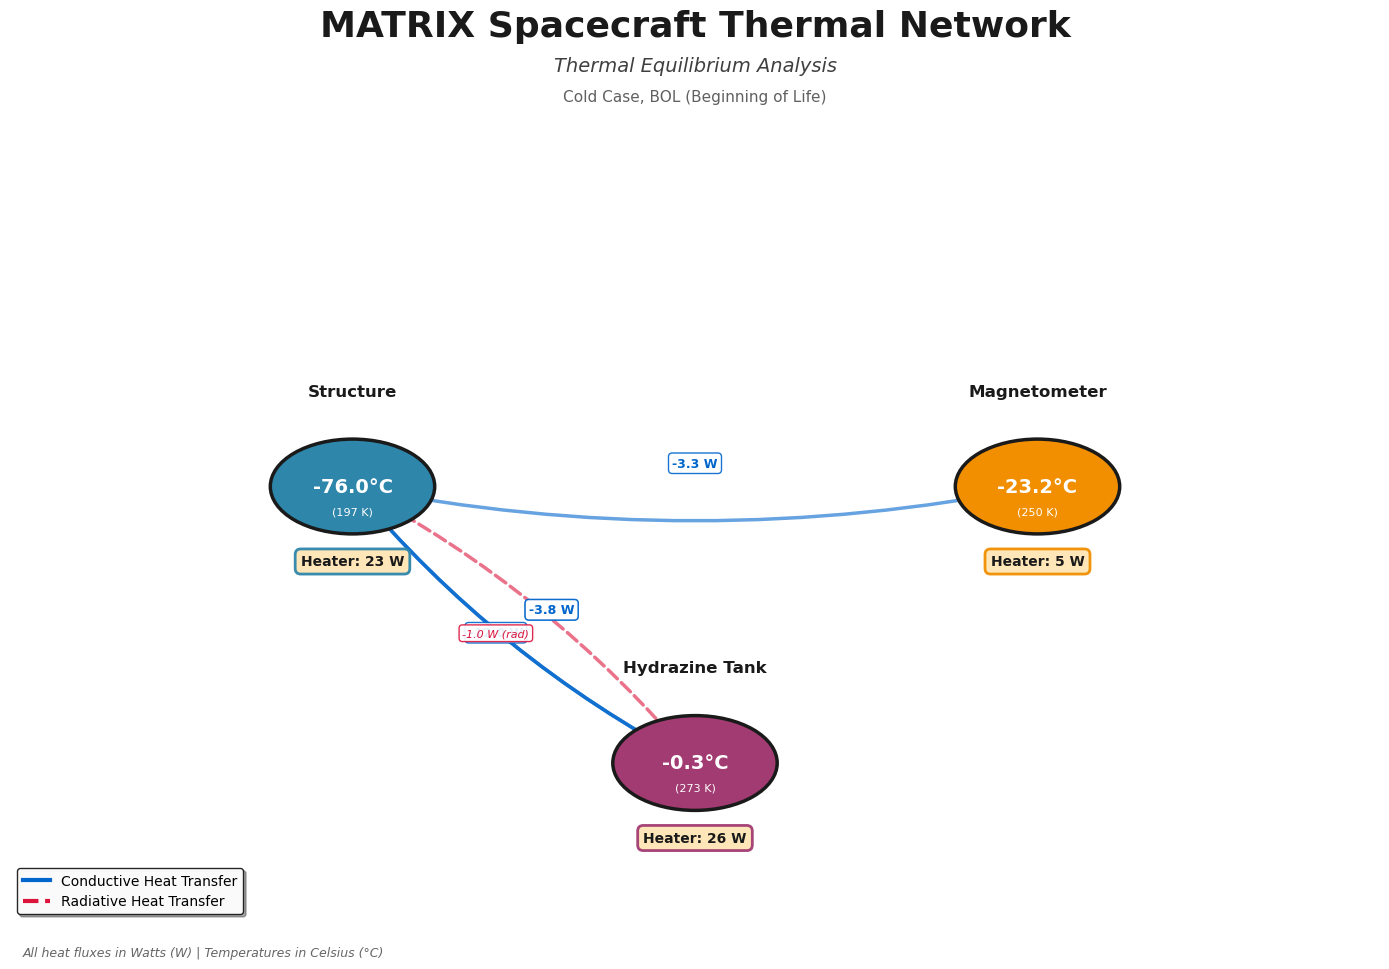

In [82]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.lines as mlines
import numpy as np

def visualize_thermal_equilibrium(temps, heaters, nodeNames, cond, rad, title="MATRIX Spacecraft Thermal Network", 
                                   subtitle="Thermal Equilibrium Analysis", case_info="BOL, Hot Case"):
    """
    Create a professional poster-quality thermal equilibrium visualization.
    
    Parameters:
    - temps: array of equilibrium temperatures (K) for each node
    - heaters: array of heater powers (W) for each node
    - nodeNames: list of node names
    - cond: list of ConductiveConnection objects
    - rad: list of RadiativeConnection objects
    - title: main title for the plot
    - subtitle: subtitle describing the analysis
    - case_info: environmental case information
    """
    
    fig, ax = plt.subplots(figsize=(14, 10), facecolor='white')
    ax.set_facecolor('white')
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Title section
    fig.text(0.5, 0.94, title, ha='center', fontsize=26, fontweight='bold', color='#1a1a1a')
    fig.text(0.5, 0.905, subtitle, ha='center', fontsize=14, style='italic', color='#404040')
    fig.text(0.5, 0.875, case_info, ha='center', fontsize=11, color='#606060')
    
    # Node positions (strategic placement for 3 nodes)
    node_positions = {
        0: (2.5, 5.5),      # Structure (left)
        1: (5.0, 2.0),      # Hydrazine (bottom middle)
        2: (7.5, 5.5)       # Magnetometer (right)
    }
    
    # Node colors (professional palette)
    node_colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange
    
    # Draw connection lines first (so they appear behind nodes)
    cond_counter = {}  # Track number of connections between each node pair
    for conn_idx, conn in enumerate(cond):
        n1_idx = conn.node1_idx
        n2_idx = conn.node2_idx
        
        x1, y1 = node_positions[n1_idx]
        x2, y2 = node_positions[n2_idx]
        
        # Calculate heat transfer
        q_cond = conn.calculate_heat_transfer(temps[n1_idx], temps[n2_idx])
        
        # Fixed line width for all connections
        line_width = 2.5
        
        # Draw line with direction indicator
        arrow = FancyArrowPatch((x1, y1), (x2, y2),
                               arrowstyle='-', mutation_scale=0,
                               linewidth=line_width, 
                               color='#0066CC', alpha=0.6, 
                               connectionstyle="arc3,rad=0.1", zorder=1)
        ax.add_patch(arrow)
        
        # Calculate perpendicular offset for label placement
        dx = x2 - x1
        dy = y2 - y1
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            # Perpendicular direction (rotated 90 degrees)
            perp_x = -dy / length
            perp_y = dx / length
        else:
            perp_x, perp_y = 0, 1
        
        # Alternate offset direction for duplicate connections
        pair_key = tuple(sorted([n1_idx, n2_idx]))
        if pair_key not in cond_counter:
            cond_counter[pair_key] = 0
        else:
            cond_counter[pair_key] += 1
        
        offset_sign = 1 if cond_counter[pair_key] % 2 == 0 else -1
        offset_dist = 0.25
        
        # Add heat transfer label near the line
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        label_x = mid_x + offset_sign * perp_x * offset_dist
        label_y = mid_y + offset_sign * perp_y * offset_dist
        
        ax.text(label_x, label_y, f'{q_cond:.1f} W',
                fontsize=9, ha='center', bbox=dict(boxstyle='round,pad=0.3', 
                facecolor='white', edgecolor='#0066CC', linewidth=1, alpha=0.9),
                color='#0066CC', fontweight='bold')
    
    # Draw radiative connection lines (dashed)
    for rad_idx, rconn in enumerate(rad):
        n1_idx = rconn.node1_idx
        n2_idx = rconn.node2_idx
        
        x1, y1 = node_positions[n1_idx]
        x2, y2 = node_positions[n2_idx]
        
        # Calculate radiative heat transfer
        q_rad = rconn.calculate_heat_transfer(temps[n1_idx], temps[n2_idx])
        
        # Fixed line width for all connections
        line_width = 2.5
        
        # Draw dashed line for radiative
        arrow = FancyArrowPatch((x1, y1), (x2, y2),
                               arrowstyle='-', mutation_scale=0,
                               linewidth=line_width, linestyle='--',
                               color='#DC143C', alpha=0.6, 
                               connectionstyle="arc3,rad=-0.1", zorder=1)
        ax.add_patch(arrow)
        
        # Calculate perpendicular offset for label placement
        dx = x2 - x1
        dy = y2 - y1
        length = np.sqrt(dx**2 + dy**2)
        if length > 0:
            # Perpendicular direction (rotated 90 degrees, opposite for radiative)
            perp_x = dy / length
            perp_y = -dx / length
        else:
            perp_x, perp_y = 0, -1
        
        offset_dist = 0.25
        
        # Add radiative heat transfer label near the line
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        label_x = mid_x + perp_x * offset_dist
        label_y = mid_y + perp_y * offset_dist
        
        ax.text(label_x, label_y, f'{q_rad:.1f} W (rad)',
                fontsize=8, ha='center', style='italic',
                bbox=dict(boxstyle='round,pad=0.3', 
                facecolor='white', edgecolor='#DC143C', linewidth=1, alpha=0.9),
                color='#DC143C')
    
    # Draw nodes
    for node_idx, (x, y) in node_positions.items():
        # Node circle
        circle = mpatches.Circle((x, y), 0.6, color=node_colors[node_idx], 
                                ec='#1a1a1a', linewidth=2.5, zorder=5)
        ax.add_patch(circle)
        
        # Node name
        ax.text(x, y + 1.15, nodeNames[node_idx], 
               fontsize=12, fontweight='bold', ha='center', color='#1a1a1a')
        
        # Temperature (large, prominent)
        temp_c = temps[node_idx] - 273.15
        ax.text(x, y, f'{temp_c:.1f}°C', 
               fontsize=14, fontweight='bold', ha='center', va='center',
               color='white', zorder=6)
        
        # Temperature in Kelvin (smaller)
        ax.text(x, y - 0.25, f'({temps[node_idx]:.0f} K)', 
               fontsize=8, ha='center', va='top', color='white', zorder=6)
        
        # Heater input (below node)
        ax.text(x, y - 1.0, f'Heater: {heaters[node_idx]} W',
               fontsize=10, ha='center', fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFE5B4', 
                        edgecolor=node_colors[node_idx], linewidth=2, alpha=0.95),
               color='#1a1a1a')
    
    # Legend
    cond_line = mlines.Line2D([], [], color='#0066CC', linewidth=3, label='Conductive Heat Transfer')
    rad_line = mlines.Line2D([], [], color='#DC143C', linewidth=3, linestyle='--', label='Radiative Heat Transfer')
    
    ax.legend(handles=[cond_line, rad_line], 
             loc='lower left', fontsize=10, framealpha=0.95, 
             fancybox=True, shadow=True, edgecolor='#1a1a1a')
    
    # Add units reminder
    fig.text(0.02, 0.02, 'All heat fluxes in Watts (W) | Temperatures in Celsius (°C)', 
            fontsize=9, ha='left', color='#666666', style='italic')
    
    plt.tight_layout(rect=[0, 0.04, 1, 0.86])
    plt.show()

# Run visualization with current heater setup
heaters = [23, 26, 5]  # Updated to 3 nodes
temps = matrix.eqTemp(env=envCold, BOL=True, heaters=heaters)

print(f"\n{'='*70}")
print(f"{'THERMAL EQUILIBRIUM SUMMARY':^70}")
print(f"{'='*70}")
print(f"\nEquilibrium Temperatures:")
for i, node in enumerate(matrix.nodes):
    print(f"  {nodeNames[i]:<20} {temps[i]-273.15:>8.2f} °C  ({temps[i]:>7.1f} K)")

print(f"\nHeater Inputs:")
for i, h in enumerate(heaters):
    print(f"  {nodeNames[i]:<20} {h:>8.1f} W")

print(f"\nConductive Heat Transfer Rates:")
for i, cond_conn in enumerate(matrix.cond):
    q = cond_conn.calculate_heat_transfer(temps[cond_conn.node1_idx], temps[cond_conn.node2_idx])
    node1 = nodeNames[cond_conn.node1_idx]
    node2 = nodeNames[cond_conn.node2_idx]
    direction = "→" if q > 0 else "←"
    print(f"  {node1} {direction} {node2:<20} {abs(q):>8.2f} W")

print(f"\nRadiative Heat Transfer Rates:")
for i, rad_conn in enumerate(matrix.rad):
    q = rad_conn.calculate_heat_transfer(temps[rad_conn.node1_idx], temps[rad_conn.node2_idx])
    node1 = nodeNames[rad_conn.node1_idx]
    node2 = nodeNames[rad_conn.node2_idx]
    direction = "→" if q > 0 else "←"
    print(f"  {node1} {direction} {node2:<20} {abs(q):>8.2f} W")

print(f"\n{'='*70}\n")

# Create the visualization
visualize_thermal_equilibrium(temps, heaters, nodeNames, matrix.cond, matrix.rad,
                             title="MATRIX Spacecraft Thermal Network",
                             subtitle="Thermal Equilibrium Analysis",
                             case_info="Cold Case, BOL (Beginning of Life)")
